TRABAJO PRACTICO N° 1 - NEURONA ARTIFICIAL - PERCEPTRON

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Inicializa la neurona con pesos al azar
def initialize_neuron(input_size):
    weights = np.random.rand(input_size)
    bias = np.random.rand(1)
    return weights, bias

weights, bias = initialize_neuron(2)  # Para una neurona con 2 entradas
print("Pesos iniciales:", weights)
print("Bias inicial:", bias)


Pesos iniciales: [0.30268012 0.12658395]
Bias inicial: [0.34395292]


Output de la neurona: [0.63024504]


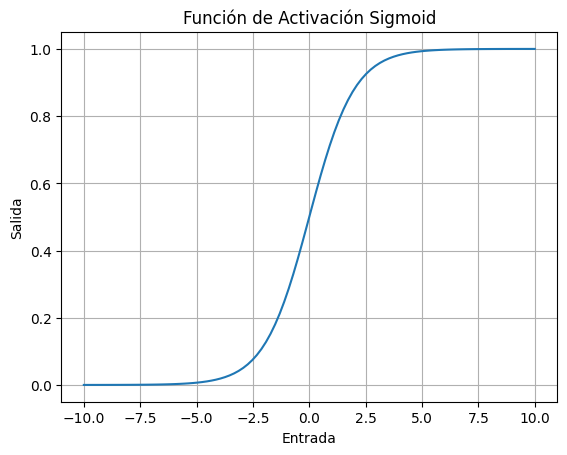

In [4]:
# Funcion de activacion Sigmoid 
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Forward pass through the neuron
def forward_pass(inputs, weights, bias):
    linear_output = np.dot(inputs, weights) + bias
    activated_output = sigmoid(linear_output)
    return activated_output
# Example input
inputs = np.array([0.5, 0.3])
output = forward_pass(inputs, weights, bias)
print("Output de la neurona:", output)

# Visualización de la función de activación Sigmoid
x = np.linspace(-10, 10, 100)
y = sigmoid(x)
plt.plot(x, y)
plt.title('Función de Activación Sigmoid')
plt.xlabel('Entrada')
plt.ylabel('Salida')
plt.grid()
plt.show()


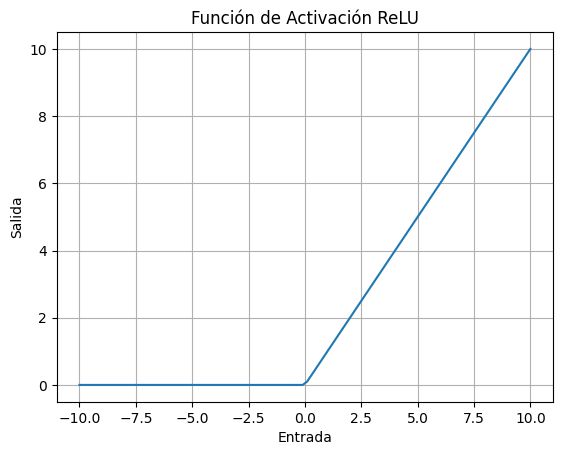

In [5]:
#ReLu
def relu(x):
    return np.maximum(0, x)
# Visualización de la función ReLU
y_relu = relu(x)
plt.plot(x, y_relu)
plt.title('Función de Activación ReLU')
plt.xlabel('Entrada')
plt.ylabel('Salida')
plt.grid()
plt.show()


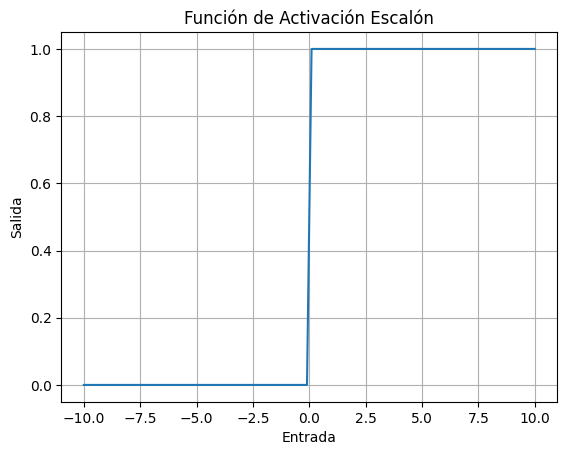

In [6]:
# Funcion de activacion Escalon 
def step(x):
    return np.where(x >= 0, 1, 0)
# Visualización de la función escalón
y_step = step(x)
plt.plot(x, y_step)
plt.title('Función de Activación Escalón')
plt.xlabel('Entrada')
plt.ylabel('Salida')
plt.grid()
plt.show()


In [8]:
# Forward pass through the neuron
def forward_pass(inputs, weights, bias):
    z = np.dot(inputs, weights) + bias
    return z

In [9]:
# seteo de valores a mano
weights = np.array([1, 1]) 
bias = np.array([-1.5]) 
output=forward_pass([0.5,1],weights,bias)[0]
print(output)  

0.0


Con una neurona, especialmente si se usa la función escalón como función de activación. es posible diseñar los circuitos lógicos AND, OR, NOT. 

Verifique que con los siguientes paràmetros (w1=1, w2=1, b=−1.5 ) la neurona resuelve correctamente la función AND.



CIRCUITO LOGICO AND

In [25]:
# Inicializa la neurona con pesos y bias a mano
def initialize_neuron(input_size):
    weights = np.array([1, 1])  # Pesos fijos para la función AND
    bias = np.array([-1.5])  # Bias fijo para la función AND
    return weights, bias

weights, bias = initialize_neuron(2)  # Para una neurona con 2 entradas
print("Pesos iniciales:", weights)
print("Bias inicial:", bias)

Pesos iniciales: [1 1]
Bias inicial: [-1.5]


In [26]:
# Funcion de activacion Escalon 
def step(x):
    return np.where(x >= 0, 1, 0)

# Forward pass through the neuron
def forward_pass(inputs, weights, bias):
    z = np.dot(inputs, weights) + bias
    activated_output = step(z)
    return activated_output

# Test de la neurona con la función AND
inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # Entradas para la función AND
output = forward_pass(inputs, weights, bias)
print("Output de la neurona (AND):", output)


Output de la neurona (AND): [0 0 0 1]


CIRCUITO LOGICO OR

In [34]:
# Inicializa la neurona con pesos y bias a mano
def initialize_neuron(input_size):
    weights = np.array([1, 1])  # Pesos fijos para la función OR
    bias = np.array([-0.5])  # Bias fijo para la función OR
    return weights, bias

weights, bias = initialize_neuron(2)  # Para una neurona con 2 entradas
print("Pesos iniciales:", weights)
print("Bias inicial:", bias)

Pesos iniciales: [1 1]
Bias inicial: [-0.5]


In [35]:
# Funcion de activacion Escalon 
def step(x):
    return np.where(x >= 0, 1, 0)

# Forward pass through the neuron
def forward_pass(inputs, weights, bias):
    z = np.dot(inputs, weights) + bias
    activated_output = step(z)
    return activated_output

# Test de la neurona con la función OR
inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # Entradas para la función OR
output = forward_pass(inputs, weights, bias)
print("Output de la neurona (OR):", output)

Output de la neurona (OR): [0 1 1 1]


CIRCUITO LOGICO NOT

In [36]:
# Inicializa la neurona con pesos y bias a mano
def initialize_neuron(input_size):
    weights = np.array([-1, -1])  # Pesos fijos para la función NOT
    bias = np.array([0.5])  # Bias fijo para la función NOT
    return weights, bias

weights, bias = initialize_neuron(2)  # Para una neurona con 2 entradas
print("Pesos iniciales:", weights)
print("Bias inicial:", bias)

Pesos iniciales: [-1 -1]
Bias inicial: [0.5]


In [37]:
Z=np.dot([0, 0], weights) + bias
print("Output de la neurona (NOT):", step(Z))
    

Output de la neurona (NOT): [1]


1.1.2 Enseñandole (o entrenando) una neurona

In [40]:
# 1. Funciones de activación y pérdida según la consigna
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy_loss(y_pred, y_true):
    # Clip para evitar log(0) o log(1) que darían NaN
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_gradients(inputs, weights, bias, y_true):
    # Forward pass: Producto escalar + bias
    z = np.dot(weights, inputs) + bias
    y_pred = sigmoid(z)
    
    # Cálculo de la pérdida (LF)
    loss = binary_cross_entropy_loss(y_pred, y_true)
    
    # Backward pass: Cálculo de gradientes
    # Basado en la derivada de BCE + Sigmoidea: dL/dz = (y_pred - y_true)
    error_delta = y_pred - y_true
    
    d_weights = error_delta * inputs  # Gradientes para w1 y w2
    d_bias = error_delta              # Gradiente para b
    
    return y_pred, loss, d_weights, d_bias

# 2. Datos de la tabla de verdad AND
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])

def ejecutar_analisis(w, b, titulo):
    print(f"\n--- {titulo} ---")
    print(f"Pesos: {w} | Bias: {b}")
    print(f"{'Input (x1,x2)':<15} | {'X1 AND X2':<7} | {'Output':<7} | {'Loss':<7} | {'Grad_W1':<18} | {'Grad_W2':<7}")
    print("-" * 85)
    
    for i in range(len(X)):
        y_p, loss, dw, db = compute_gradients(X[i], w, b, Y[i])
        
        # Formateo de salida para legibilidad
        input_str = str(X[i])
        grad_w_str = str(np.round(dw, 4))
        print(f"{input_str:<15} | {Y[i]:<7} | {y_p[0]:.4f} | {loss[0]:.4f} | {grad_w_str:<18} | {db[0]:.4f}")

# --- EXPERIMENTO 1: Parámetros cercanos (Sugeridos) ---
w_sug = np.array([5.0, 3.0])
b_sug = np.array([-7.0])
ejecutar_analisis(w_sug, b_sug, "ESCENARIO A: Parámetros cercanos a los óptimos")

# --- EXPERIMENTO 2: Parámetros al azar ---
# Usamos una semilla para que puedas replicar los resultados
np.random.seed(12) 
w_rand = np.random.uniform(-1, 1, 2)
b_rand = np.random.uniform(-1, 1, 1)
ejecutar_analisis(w_rand, b_rand, "ESCENARIO B: Parámetros al azar")


--- ESCENARIO A: Parámetros cercanos a los óptimos ---
Pesos: [5. 3.] | Bias: [-7.]
Input (x1,x2)   | X1 AND X2 | Output  | Loss    | Grad_W1            | Grad_W2
-------------------------------------------------------------------------------------
[0 0]           | 0       | 0.0009 | 0.0009 | [0. 0.]            | 0.0009
[0 1]           | 0       | 0.0180 | 0.0181 | [0.    0.018]      | 0.0180
[1 0]           | 0       | 0.1192 | 0.1269 | [0.1192 0.    ]    | 0.1192
[1 1]           | 1       | 0.7311 | 0.3133 | [-0.2689 -0.2689]  | -0.2689

--- ESCENARIO B: Parámetros al azar ---
Pesos: [-0.69167432  0.48009939] | Bias: [-0.47336997]
Input (x1,x2)   | X1 AND X2 | Output  | Loss    | Grad_W1            | Grad_W2
-------------------------------------------------------------------------------------
[0 0]           | 0       | 0.3838 | 0.4842 | [0. 0.]            | 0.3838
[0 1]           | 0       | 0.5017 | 0.6965 | [0.     0.5017]    | 0.5017
[1 0]           | 0       | 0.2378 | 0.2715 

**Ejercicio 1.1:**

a) Utilizando una neurona de dos entradas (x1, x2) y la función de activacion sigmoidea, programe un código que tomando valores de w1,w2 y b de entrada al azar,
determine los gradientes y los vaya actualizando hasta encontrar un valor optimo. 
Controle del mismo la cantidad de ciclos de entrenamiento, y el LR. 
Consejo: pruebe diferentes valores de LR, e incluso puede utilizar una funciòn donde el LR decrece a medida que avanza el entrenamiento. Ademas utilice los gradientes promedio (batch) para la actualizaciòn de los parámetros
Para monitorear el entrenamiento calcule (y grafique) el avance de la LF en función del número de ciclo y calcule y muestre los valores finales que obtiene la neurona para cada una de las 4 condiciones de entrada del AND. 

**Analice los resultados**

b) Que pasa si en lugar de una sigmoidea utiliza ReLu? 

c) Se anima a repetir el proceso pero para la función lógica “OR”


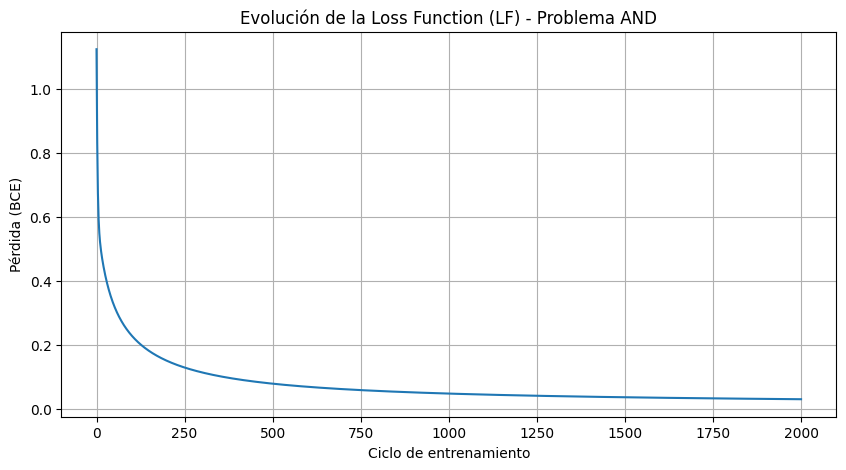

--- Valores Finales de los Parámetros ---
w1: 6.2081, w2: 6.2081, b: -9.4886

--- Verificación de Resultados Finales ---
Input: [0 0] | Target: 0 | Predicción: 0.0001
Input: [0 1] | Target: 0 | Predicción: 0.0362
Input: [1 0] | Target: 0 | Predicción: 0.0362
Input: [1 1] | Target: 1 | Predicción: 0.9492


In [41]:
# 1. Funciones base (Sigmoidea y su derivada, Loss y su derivada)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy_loss(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15) # Evitar log(0)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 2. Datos de entrenamiento (Lógica AND)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])

# 3. Inicialización de parámetros al azar
np.random.seed(42) # Para reproducibilidad
input_size = 2
weights = np.random.rand(input_size)
bias = np.random.rand(1)

# 4. Hiperparámetros
lr_inicial = 0.5    # Learning Rate
epochs = 2000       # Ciclos de entrenamiento
loss_history = []

# 5. Ciclo de Entrenamiento
for epoch in range(epochs):
    dw_batch = np.zeros(input_size)
    db_batch = 0
    total_loss = 0
    
    # Opcional: LR decreciente (como sugiere el consejo del TP)
    lr = lr_inicial / (1 + 0.001 * epoch)
    
    # Forward y Backward para cada ejemplo (acumulando para el batch)
    for i in range(len(X)):
        inputs = X[i]
        y_true = Y[i]
        
        # Forward pass
        z = np.dot(weights, inputs) + bias
        y_pred = sigmoid(z)
        
        # Calcular Loss
        total_loss += binary_cross_entropy_loss(y_pred, y_true)
        
        # Gradientes (Derivada simplificada de BCE + Sigmoidea: y_pred - y_true)
        error_delta = y_pred - y_true
        dw_batch += error_delta * inputs
        db_batch += error_delta
    
    # Actualización de parámetros usando el promedio del batch
    weights -= lr * (dw_batch / len(X))
    bias -= lr * (db_batch / len(X))
    
    # Guardar pérdida promedio para graficar
    loss_history.append(total_loss / len(X))

# 6. Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title("Evolución de la Loss Function (LF) - Problema AND")
plt.xlabel("Ciclo de entrenamiento")
plt.ylabel("Pérdida (BCE)")
plt.grid(True)
plt.show()

print("--- Valores Finales de los Parámetros ---")
print(f"w1: {weights[0]:.4f}, w2: {weights[1]:.4f}, b: {bias[0]:.4f}")

print("\n--- Verificación de Resultados Finales ---")
for i in range(len(X)):
    z = np.dot(weights, X[i]) + bias
    pred = sigmoid(z)
    print(f"Input: {X[i]} | Target: {Y[i]} | Predicción: {pred[0]:.4f}")

b) Evaluacion de LF con ReLU

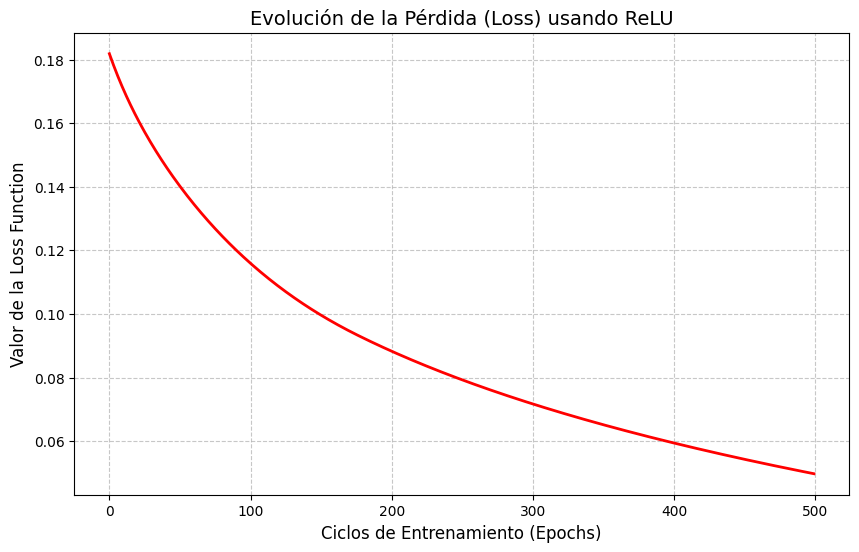

Resultados finales con ReLU:
Input: [0 0] | Predicción: 0.0000
Input: [0 1] | Predicción: 0.2458
Input: [1 0] | Predicción: 0.1988
Input: [1 1] | Predicción: 0.6857


In [42]:
# 1. Funciones para ReLU
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Para ReLU, usamos el Error Cuadrático Medio (MSE) como Loss Function
def mse_loss(y_pred, y_true):
    return (y_pred - y_true) ** 2

# 2. Datos del AND
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])

# 3. Inicialización azarosa
np.random.seed(42)
weights = np.random.uniform(-0.5, 0.5, 2)
bias = np.random.uniform(-0.5, 0.5, 1)

# 4. Hiperparámetros
lr = 0.01
epochs = 500
loss_history = []

# 5. Ciclo de entrenamiento (Batch)
for epoch in range(epochs):
    dw_batch = np.zeros(2)
    db_batch = 0
    total_loss = 0
    
    for i in range(len(X)):
        # Forward Pass
        z = np.dot(X[i], weights) + bias
        y_pred = relu(z)
        
        # Cálculo de pérdida
        loss = mse_loss(y_pred, Y[i])
        total_loss += loss
        
        # Gradientes (Regla de la cadena)
        # dL/dy = 2*(y_pred - y_true)
        # dy/dz = relu_derivative(z)
        error_delta = 2 * (y_pred - Y[i]) * relu_derivative(z)
        
        dw_batch += error_delta * X[i]
        db_batch += error_delta
        
    # Actualización de parámetros (Promedio del batch)
    weights -= lr * (dw_batch / len(X))
    bias -= lr * (db_batch / len(X))
    
    loss_history.append(total_loss / len(X))

# --- GENERACIÓN DEL GRÁFICO ---
plt.figure(figsize=(10, 6))
plt.plot(loss_history, color='red', linewidth=2)
plt.title("Evolución de la Pérdida (Loss) usando ReLU", fontsize=14)
plt.xlabel("Ciclos de Entrenamiento (Epochs)", fontsize=12)
plt.ylabel("Valor de la Loss Function", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Verificación final
print("Resultados finales con ReLU:")
for i in range(len(X)):
    z = np.dot(X[i], weights) + bias
    print(f"Input: {X[i]} | Predicción: {relu(z)[0]:.4f}")

Las predicciones utilizando ReLU son mucho mas bajas que las anteriores para el caso de la funcion AND la que es verdadera con las entradas [1,1] es bastante baja.

**Funcion OR utilizando Sigmoidea**

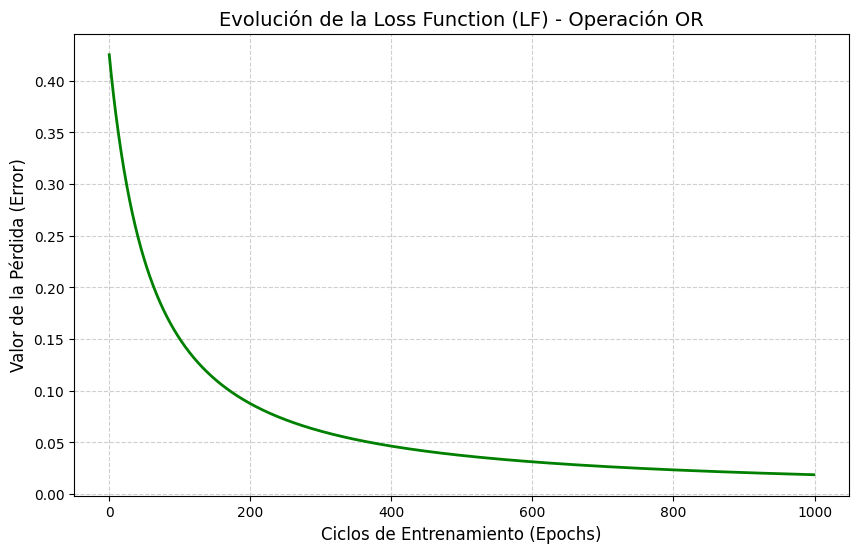

Pesos finales: [7.24826392 7.25030631], Bias final: [-3.15211478]

Predicciones finales:
Entrada: [0 0] | Predicción: 0.0410
Entrada: [0 1] | Predicción: 0.9837
Entrada: [1 0] | Predicción: 0.9836
Entrada: [1 1] | Predicción: 1.0000


In [43]:
# 1. Funciones base (Sigmoidea y Loss)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy_loss(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15) # Para evitar errores matemáticos
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 2. Datos para la función lógica OR
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 1, 1, 1]) 

# 3. Inicialización azarosa de parámetros
np.random.seed(42)
weights = np.random.rand(2)
bias = np.random.rand(1)

# 4. Hiperparámetros
lr = 0.5
epochs = 1000
loss_history = [] # Lista para guardar el error de cada ciclo

# 5. Ciclo de entrenamiento (Batch Gradient Descent)
for epoch in range(epochs):
    dw_batch = np.zeros(2)
    db_batch = 0
    total_loss = 0
    
    for i in range(len(X)):
        # Forward pass
        z = np.dot(X[i], weights) + bias
        y_pred = sigmoid(z)
        
        # Calcular pérdida
        total_loss += binary_cross_entropy_loss(y_pred, Y[i])
        
        # Calcular gradientes (derivada simplificada de BCE + Sigmoidea)
        error_delta = y_pred - Y[i]
        dw_batch += error_delta * X[i]
        db_batch += error_delta
        
    # Actualización de parámetros usando el promedio del batch
    weights -= lr * (dw_batch / len(X))
    bias -= lr * (db_batch / len(X))
    
    # Guardamos la pérdida promedio de este ciclo para la gráfica
    loss_history.append(total_loss / len(X))

# --- CÓDIGO PARA LA GRÁFICA ---
plt.figure(figsize=(10, 6))
plt.plot(loss_history, color='green', linewidth=2)
plt.title("Evolución de la Loss Function (LF) - Operación OR", fontsize=14)
plt.xlabel("Ciclos de Entrenamiento (Epochs)", fontsize=12)
plt.ylabel("Valor de la Pérdida (Error)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Verificación final de la tabla de verdad
print(f"Pesos finales: {weights}, Bias final: {bias}")
print("\nPredicciones finales:")
for i in range(len(X)):
    z = np.dot(X[i], weights) + bias
    print(f"Entrada: {X[i]} | Predicción: {sigmoid(z)[0]:.4f}")

El calculo es bastante certero puesto que la unica salida [0.0] es False, entonces la prediccion en este caso es baja, y las otras entradas se aproximan a 1.